In [ ]:
# Predicting 30-Day Readmission in Diabetic Patients

##Question: Which diabetic patients are at highest risk of being readmitted within 30 days of discharge, and what should hospitals act on to reduce it?

##Data: 101,766 inpatient encounters across 130 US hospitals (1999-2008), from the UCI Diabetes 130-US Hospitals dataset.

## Approach: Clean and engineer features from raw EHR data, compare a logistic regression baseline against XGBoost, and identify the strongest predictors of readmission risk.

In [51]:
import pandas as pd

df = pd.read_csv('diabetic_data.csv')
df.replace('?', pd.NA, inplace=True)
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [53]:
print(df['readmitted'].value_counts())
print()
print(df.isna().mean().sort_values(ascending=False).head(10))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

weight               0.968585
max_glu_serum        0.947468
A1Cresult            0.832773
medical_specialty    0.490822
payer_code           0.395574
race                 0.022336
diag_3               0.013983
diag_2               0.003518
diag_1               0.000206
encounter_id         0.000000
dtype: float64


In [54]:
df['readmit_30d'] = (df['readmitted'] =='<30').astype(int)
print(df['readmit_30d'].value_counts())

readmit_30d
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
## Exploratory Data Analysis

## Roughly 11% of patients were readmitted within 30 days. Readmission risk does **not** rise steadily with age as might be expected — it spikes unexpectedly in the 20s before climbing again after 60. The clearest driver, however, is prior hospital utilization: patients with a history of multiple inpatient visits show a dramatic, near-linear increase in readmission risk.

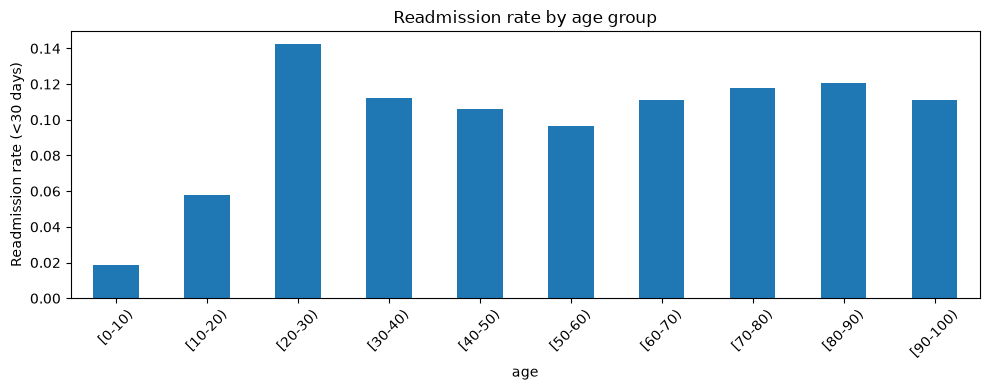

In [55]:
import matplotlib.pyplot as plt

df.groupby('age')['readmit_30d'].mean().plot(kind='bar', figsize=(10,4))
plt.ylabel('Readmission rate (<30 days)')
plt.title('Readmission rate by age group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

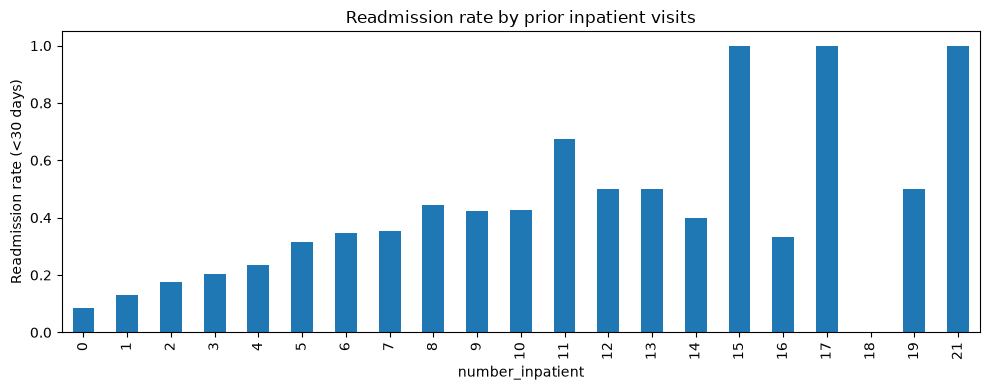

In [56]:
df.groupby('number_inpatient')['readmit_30d'].mean().plot(kind='bar', figsize=(10,4))
plt.ylabel('Readmission rate (<30 days)')
plt.title('Readmission rate by prior inpatient visits')
plt.tight_layout()
plt.show()

In [57]:
df_clean = df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult', 'payer_code'])
df_clean = df_clean.dropna(subset=['race', 'diag_1', 'diag_2', 'diag_3'])
print(df_clean.shape)


(98053, 47)


In [58]:
print(df['race'].isna().sum())

2273


In [59]:
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Unknown')
print(df_clean['medical_specialty'].value_counts().head(10))

medical_specialty
Unknown                       48318
InternalMedicine              13967
Emergency/Trauma               7472
Family/GeneralPractice         7140
Cardiology                     5218
Surgery-General                2969
Nephrology                     1581
Orthopedics                    1355
Orthopedics-Reconstructive     1150
Radiologist                    1115
Name: count, dtype: int64


In [60]:
top_specialties = df_clean['medical_specialty'].value_counts().head(9).index
df_clean['specialty_grouped'] = df_clean['medical_specialty'].where(
    df_clean['medical_specialty'].isin(top_specialties), 'Other'
)
print(df_clean['specialty_grouped'].value_counts())

specialty_grouped
Unknown                       48318
InternalMedicine              13967
Other                          8883
Emergency/Trauma               7472
Family/GeneralPractice         7140
Cardiology                     5218
Surgery-General                2969
Nephrology                     1581
Orthopedics                    1355
Orthopedics-Reconstructive     1150
Name: count, dtype: int64


In [61]:
def map_diagnosis(code):
    try:
        code = str(code)
        if code.startswith('250'):
            return 'Diabetes'
        code_num = float(code)
        if 390 <= code_num <= 459 or code_num == 785:
            return 'Circulatory'
        elif 460 <= code_num <= 519 or code_num == 787:
            return 'Digestive'
        elif 800 <= code_num <= 999:
            return 'Injury'
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'
        elif 580 <= code_num <= 629 or code_num == 788:
            return 'Genitourinary'
        elif 140 <= code_num <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except ValueError:
        return 'Other'
    

In [62]:
df_clean['diag_1_group'] = df_clean['diag_1'].apply(map_diagnosis)
print(df_clean['diag_1_group'].value_counts())

diag_1_group
Other              30369
Circulatory        29630
Digestive          10352
Diabetes            7965
Injury              6703
Genitourinary       4983
Musculoskeletal     4739
Neoplasms           3312
Name: count, dtype: int64


In [63]:
df_clean['diag_2_group'] = df_clean['diag_2'].apply(map_diagnosis)
df_clean['diag_3_group'] = df_clean['diag_3'].apply(map_diagnosis)
print(df_clean[['diag_1_group', 'diag_2_group', 'diag_3_group']].head())

  diag_1_group diag_2_group diag_3_group
1        Other     Diabetes        Other
2        Other     Diabetes        Other
3        Other     Diabetes  Circulatory
4    Neoplasms    Neoplasms     Diabetes
5  Circulatory  Circulatory     Diabetes


In [64]:
df_model = df_clean.drop(columns=['diag_1', 'diag_2', 'diag_3', 'medical_specialty', 'readmitted', 'encounter_id', 'patient_nbr'])
print(df_model.shape)

(98053, 44)


In [65]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 98053 entries, 1 to 101765
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   race                      98053 non-null  str  
 1   gender                    98053 non-null  str  
 2   age                       98053 non-null  str  
 3   admission_type_id         98053 non-null  int64
 4   discharge_disposition_id  98053 non-null  int64
 5   admission_source_id       98053 non-null  int64
 6   time_in_hospital          98053 non-null  int64
 7   num_lab_procedures        98053 non-null  int64
 8   num_procedures            98053 non-null  int64
 9   num_medications           98053 non-null  int64
 10  number_outpatient         98053 non-null  int64
 11  number_emergency          98053 non-null  int64
 12  number_inpatient          98053 non-null  int64
 13  number_diagnoses          98053 non-null  int64
 14  metformin                 98053 non-null  str  
 15  

In [66]:
df_encoded = pd.get_dummies(df_model, drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(98053, 106)


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmit_30d,race_Asian,race_Caucasian,race_Hispanic,race_Other,gender_Male,gender_Unknown/Invalid,age_[10-20),age_[20-30),age_[30-40),age_[40-50),age_[50-60),age_[60-70),age_[70-80),age_[80-90),age_[90-100),metformin_No,metformin_Steady,metformin_Up,repaglinide_No,repaglinide_Steady,repaglinide_Up,nateglinide_No,nateglinide_Steady,nateglinide_Up,chlorpropamide_No,chlorpropamide_Steady,chlorpropamide_Up,glimepiride_No,...,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,specialty_grouped_Emergency/Trauma,specialty_grouped_Family/GeneralPractice,specialty_grouped_InternalMedicine,specialty_grouped_Nephrology,specialty_grouped_Orthopedics,specialty_grouped_Orthopedics-Reconstructive,specialty_grouped_Other,specialty_grouped_Surgery-General,specialty_grouped_Unknown,diag_1_group_Diabetes,diag_1_group_Digestive,diag_1_group_Genitourinary,diag_1_group_Injury,diag_1_group_Musculoskeletal,diag_1_group_Neoplasms,diag_1_group_Other,diag_2_group_Diabetes,diag_2_group_Digestive,diag_2_group_Genitourinary,diag_2_group_Injury,diag_2_group_Musculoskeletal,diag_2_group_Neoplasms,diag_2_group_Other,diag_3_group_Diabetes,diag_3_group_Digestive,diag_3_group_Genitourinary,diag_3_group_Injury,diag_3_group_Musculoskeletal,diag_3_group_Neoplasms,diag_3_group_Other
1,1,1,7,3,59,0,18,0,0,0,9,0,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,...,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,1,1,7,2,11,5,13,2,0,1,6,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,1,7,2,44,1,16,0,0,0,7,0,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,...,False,True,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1,1,7,1,51,0,8,0,0,0,5,0,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,...,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False
5,2,1,2,3,31,6,16,0,0,0,9,0,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,...,True,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [67]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['readmit_30d'])
y = df_encoded['readmit_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(78442, 105) (19611, 105)
0.11286045740802121 0.11284483198205089


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6357454074713544
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17398
           1       0.17      0.51      0.25      2213

    accuracy                           0.66     19611
   macro avg       0.54      0.60      0.52     19611
weighted avg       0.83      0.66      0.72     19611



/Users/tfox/hospital-readmission-project/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.635799508874578
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     17398
           1       0.17      0.52      0.26      2213

    accuracy                           0.66     19611
   macro avg       0.54      0.60      0.52     19611
weighted avg       0.83      0.66      0.72     19611



In [85]:
## Modeling

## Given the ~11% class imbalance, we evaluate using ROC-AUC and recall rather than raw accuracy. Logistic regression serves as an interpretable baseline; XGBoost is used to capture non-linear patterns like the prior-visits relationship found in EDA.

In [70]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [71]:
%pip install -U xgboost

Note: you may need to restart the kernel to use updated packages.


In [72]:
from xgboost import XGBClassifier
print('XGBoost is working')

XGBoost is working


In [73]:
import re

df_encoded.columns = [re.sub(r'[\[\]<>]', '', col) for col in df_encoded.columns]

In [75]:
import re

X_train.columns = [re.sub(r'[\[\]<>]', '', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<>]', '', col) for col in X_test.columns]

In [76]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

ROC-AUC: 0.6609535576204879
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     17398
           1       0.18      0.56      0.27      2213

    accuracy                           0.66     19611
   macro avg       0.55      0.62      0.52     19611
weighted avg       0.84      0.66      0.72     19611



In [77]:
import pandas as pd

importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)
print(top_features)

number_inpatient                                0.111048
discharge_disposition_id                        0.036050
diag_1_group_Musculoskeletal                    0.020589
diabetesMed_Yes                                 0.016434
specialty_grouped_Orthopedics-Reconstructive    0.015135
metformin_Steady                                0.014962
number_diagnoses                                0.014135
glipizide_Steady                                0.014020
age_50-60)                                      0.013526
diag_1_group_Other                              0.012946
diag_3_group_Neoplasms                          0.012824
specialty_grouped_Surgery-General               0.012734
number_emergency                                0.012593
glyburide_No                                    0.012371
diag_1_group_Diabetes                           0.012045
dtype: float32


In [79]:
%pip install streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 6.6 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 kB 16.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 14.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 23.7 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 19.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [streamlit]14 [streamlit]
Note: you may need to restart the kernel to use updated packages.


In [80]:
import joblib

joblib.dump(xgb, 'xgb_model.pkl')
df_encoded.to_csv('dashboard_data.csv', index=False)

In [86]:
## Findings & Recommendations

## XGBoost outperformed the logistic regression baseline (ROC-AUC 0.66 vs. 0.64, recall 56% vs. 52% on readmitted patients).

## Top predictor: Number of prior inpatient visits — by far the strongest signal, consistent with both EDA and feature importance.

## Other key drivers: Discharge disposition, number of diagnoses, number of emergency visits, and diabetes medication management (metformin, glipizide, glyburide) at discharge.

## Recommendation: Hospitals should prioritize discharge planning and follow-up scheduling for patients with 2+ prior inpatient admissions, and ensure diabetes medication regimens are clearly managed before discharge — this group accounts for a disproportionate share of 30-day readmissions.

## Limitations: This dataset lacks social/behavioral factors (housing stability, medication adherence, caregiver support) that likely influence readmission but aren't captured in EHR data. Future work could incorporate these if available.